# Actividad final
## Microcredencial en Ciencia de Datos — Universidad de Oviedo

**Objetivo**:   
**Dataset**:   
**Variable objetivo**: `target`  

---

## Índice
1. Carga y exploración inicial

---

> **Cómo leer este notebook**: Cada sección comienza con una explicación en texto de **qué vamos a hacer** y **por qué**. Después viene el código. Al final de cada sección hay una celda de conclusiones. No ejecutes el código antes de leer el texto — el análisis es tan importante como el resultado.

---
## 0. Carga de librerías

Importamos todas las librerías que necesitamos. Usamos `warnings.filterwarnings('ignore')` para no contaminar la salida del notebook con avisos de deprecación — en producción lo quitaríamos.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler

---
## 1. Carga y exploración inicial

### ¿Qué hacemos aquí?
Antes de hacer nada con los datos, necesitamos responder cuatro preguntas básicas:
1. **¿Cuántas filas y columnas tiene el dataset?** — escala del problema
2. **¿Qué tipo tiene cada variable?** — determina qué operaciones son aplicables
3. **¿Hay valores perdidos?** — dónde están y cuántos
4. **¿Qué rango de valores tiene cada variable?** — detectar si los números tienen sentido

### ¿Por qué es importante?
Un error muy común es empezar a transformar datos sin haberlos entendido. El resultado es transformaciones incorrectas que introducen errores silenciosos — el código corre sin error pero los datos están mal.

In [3]:
data = pd.read_csv("data/aug_train.csv")

In [4]:
data.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


**Observación**: Muchas variable de tipo `object` (texto). Pocas numéricas. Destacar que *target* parace binaria (0/1). Esto determina que tendremos que aplicar codificación (OHE) a a las de tipo object, mientras que las numéricas pueden entrar directamente (tras limpieza).

In [5]:
data.isnull().sum()

enrollee_id                  0
city                         0
city_development_index       0
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
last_new_job               423
training_hours               0
target                       0
dtype: int64

**Observación**: Varias variables con valores perdidos. Ahora sabemos que existe el problema. 
Revisar en la sección Imputación de valores perdidos decidiremos cómo imputarlo con información extra que obtendremos del EDA.

In [6]:
data.describe().round(2)

,enrollee_id,city_development_index,training_hours,target
count,19158.00,19158.00,19158.00,19158.00
mean,16875.36,0.83,65.37,0.25
std,9616.29,0.12,60.06,0.43
min,1.00,0.45,1.00,0.00
25%,8554.25,0.74,23.00,0.00
50%,16982.50,0.90,47.00,0.00
75%,25169.75,0.92,88.00,0.00
max,33380.00,0.95,336.00,1.00


Las que me pueden llamar la atención son training hours y enrolled_id... valores muy extremos

---
## 2. Análisis exploratorio univariado

### ¿Qué hacemos aquí?
Analizamos cada variable por separado. El objetivo es entender:
- **La forma de la distribución**: ¿simétrica? ¿asimétrica? ¿bimodal?
- **La presencia de outliers**: ¿hay valores extremos que se alejan mucho del grueso?
- **La distribución de la variable categórica**: ¿están bien balanceadas las categorías?

### ¿Por qué es importante?
La forma de la distribución determina qué transformaciones son apropiadas. Una distribución muy asimétrica puede perjudicar a ciertos modelos (la regresión lineal asume que los residuos son normales). Los outliers extremos distorsionan el escalado y afectan al entrenamiento.

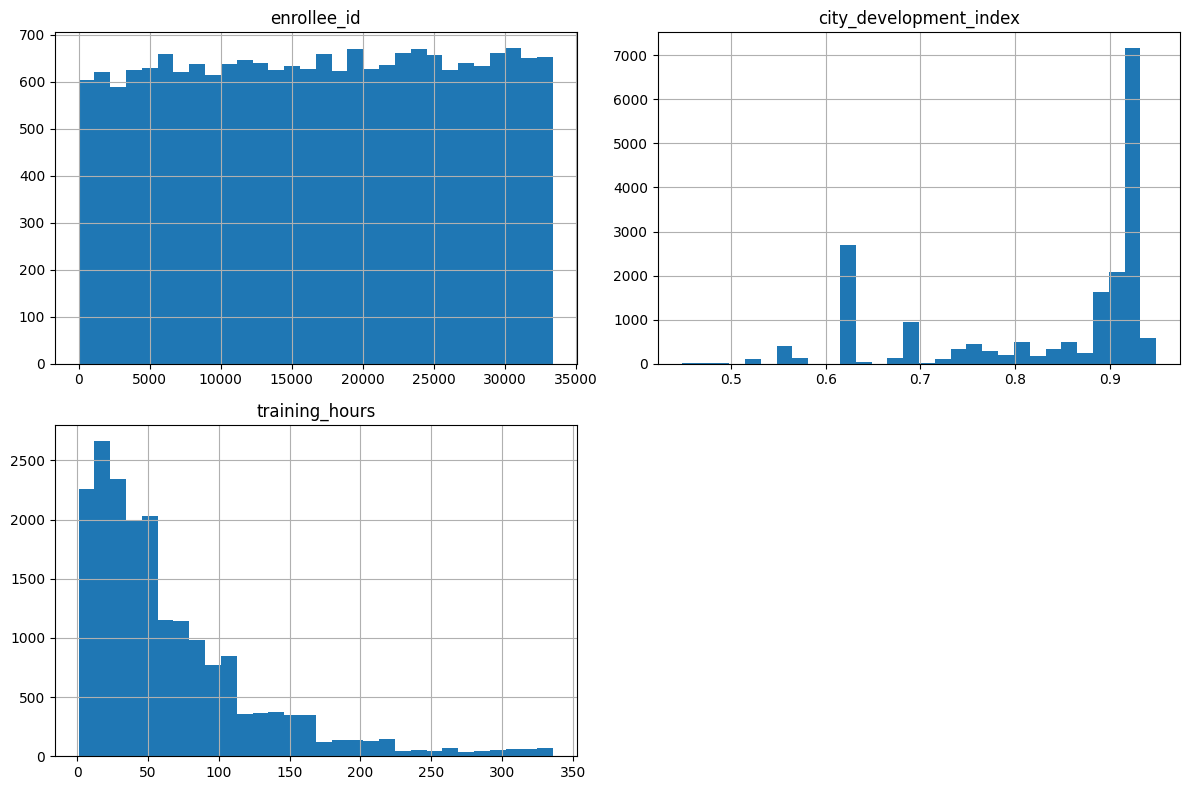

In [7]:
data.drop(["target"], axis=1).hist(bins=30, figsize=(12,8))
plt.tight_layout()
plt.show()

**Observaciones de los histogramas:**
- enrolled_id uniforme
- city development index muy variada de 0,5-1
- training hours Distribución asimétrica moderada, con cola a la derecha.

In [8]:
cols_para_hist = data.drop(["target"], axis=1).select_dtypes(include='number').columns

In [9]:
cols_para_hist

Index(['enrollee_id', 'city_development_index', 'training_hours'], dtype='object')

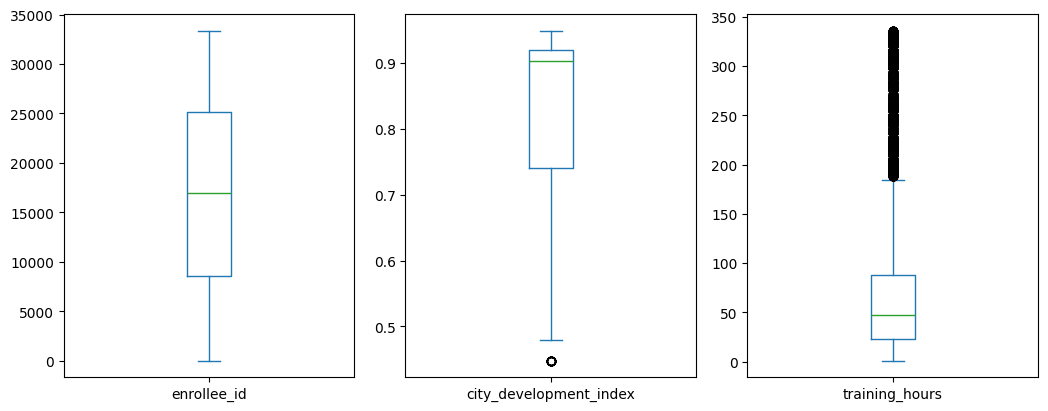

In [10]:
data[cols_para_hist].plot(kind="box", subplots=True, layout=(2,4),
                         figsize=(14,8), sharey=False)
plt.tight_layout()
plt.show()

Observaciones de los boxplots:

- enrolle_id equilibrada.
- city_development_index:  La caja (P25–P75) es grande, tiene outlier hacia abajo.
- training hours: La caja (P25–P75) es pequeña pero hay una cola enorme hacia arriba. Los puntos rojos son outliers visuales. Estos valores extremos distorsionarán el escalado y pueden afectar al entrenamiento — los trataremos en la sección *Tratamiento de outliers*.

In [15]:
data.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

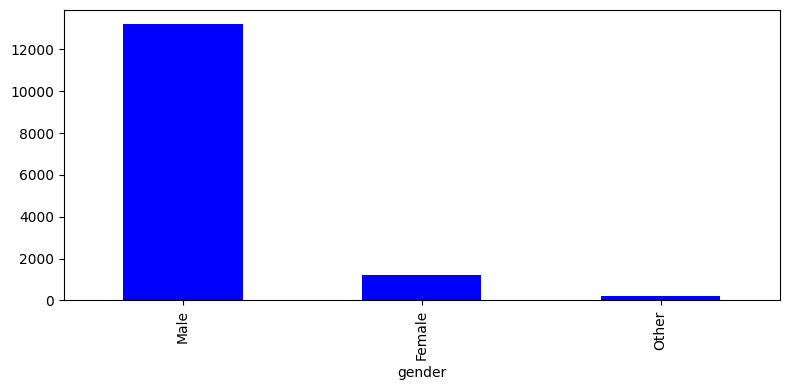

In [20]:
# Escribe aquí tu código
data['gender'].value_counts().plot(kind="bar", figsize=(8,4), color="blue")
plt.tight_layout()
plt.show()

---
## 3. Análisis exploratorio bivariado

### ¿Qué hacemos aquí?
Analizamos las relaciones entre pares de variables, con foco especial en la relación de cada variable con el **target**?. Los análisis bivariados incluyen:
- **Matriz de correlaciones de Pearson**: para variables numéricas
- **Boxplots del target por categorías**: ?
- **Test de Kruskal-Wallis**: para contrastar estadísticamente si las diferencias entre categorías son significativas

### ¿Por qué es importante?
Las correlaciones nos indican qué variables tienen relación lineal con el target — señal de que serán predictores útiles. También detectamos **multicolinealidad** entre predictores (variables que miden lo mismo), lo que motivará la creación de ratios en el feature engineering.

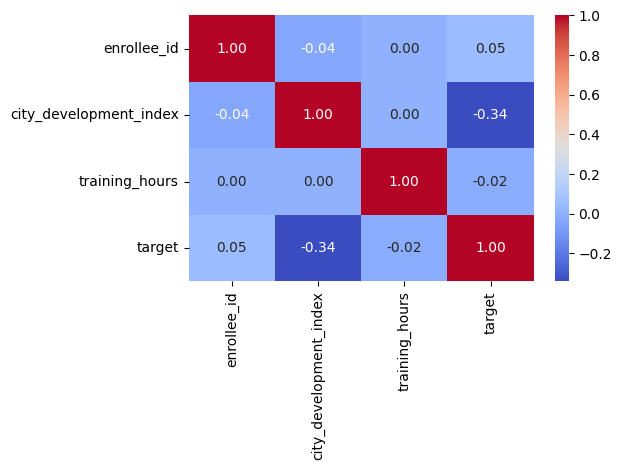

In [21]:
# Escribe aquí tu código
cols_para_pearson = data.select_dtypes(include='number').columns
corr = data[cols_para_pearson].corr()
sns.heatmap(corr, annot =True,fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

**Lecturas clave de la matriz de correlaciones:**


Variable	Correlación con target	Comentario
- city_development_index	−0.34	Correlación negativa moderada. A medida que el índice de desarrollo de la ciudad aumenta, la probabilidad de que el target sea positivo (por ejemplo, estar buscando empleo o tener cierta característica) tiende a disminuir.
- training_hours	−0.02	Prácticamente nula. Las horas de entrenamiento no parecen influir en el target.
- enrollee_id	0.05	Sin significado real; es solo un identificador. No debe usarse para análisis.

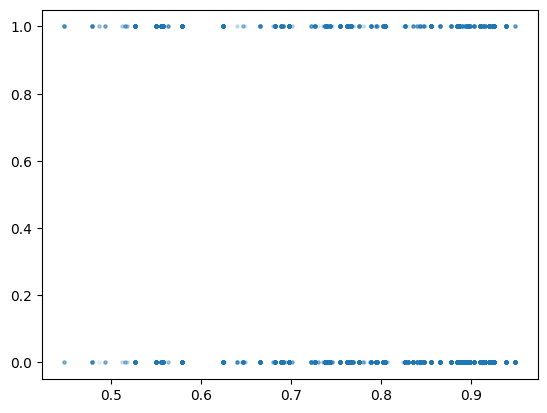

In [22]:
plt.scatter(data['city_development_index'], data['target'], alpha=0.1, s=5)
plt.show()

🧠 Interpretación
Correlación baja (≈ −0.34): el heatmap ya lo mostraba.

Visualmente: el scatter confirma que los valores del índice no separan bien las clases.

Conclusión: esta variable por sí sola no explica el comportamiento del target.

In [23]:
data.columns

Index(['enrollee_id', 'city', 'city_development_index', 'gender',
       'relevent_experience', 'enrolled_university', 'education_level',
       'major_discipline', 'experience', 'company_size', 'company_type',
       'last_new_job', 'training_hours', 'target'],
      dtype='object')

In [24]:
data.groupby("enrolled_university")["target"].mean().sort_values(ascending=False)

enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64

In [25]:
# check distribution of target for enrolled_university == 'no_enrollment'
no_enroll = data[data['enrolled_university'] == 'no_enrollment']
print(no_enroll['target'].value_counts())
print("Fraction target==1:", (no_enroll['target'] == 1).mean())

target
0.0    10896
1.0     2921
Name: count, dtype: int64
Fraction target==1: 0.21140623869146705


C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\2063327819.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

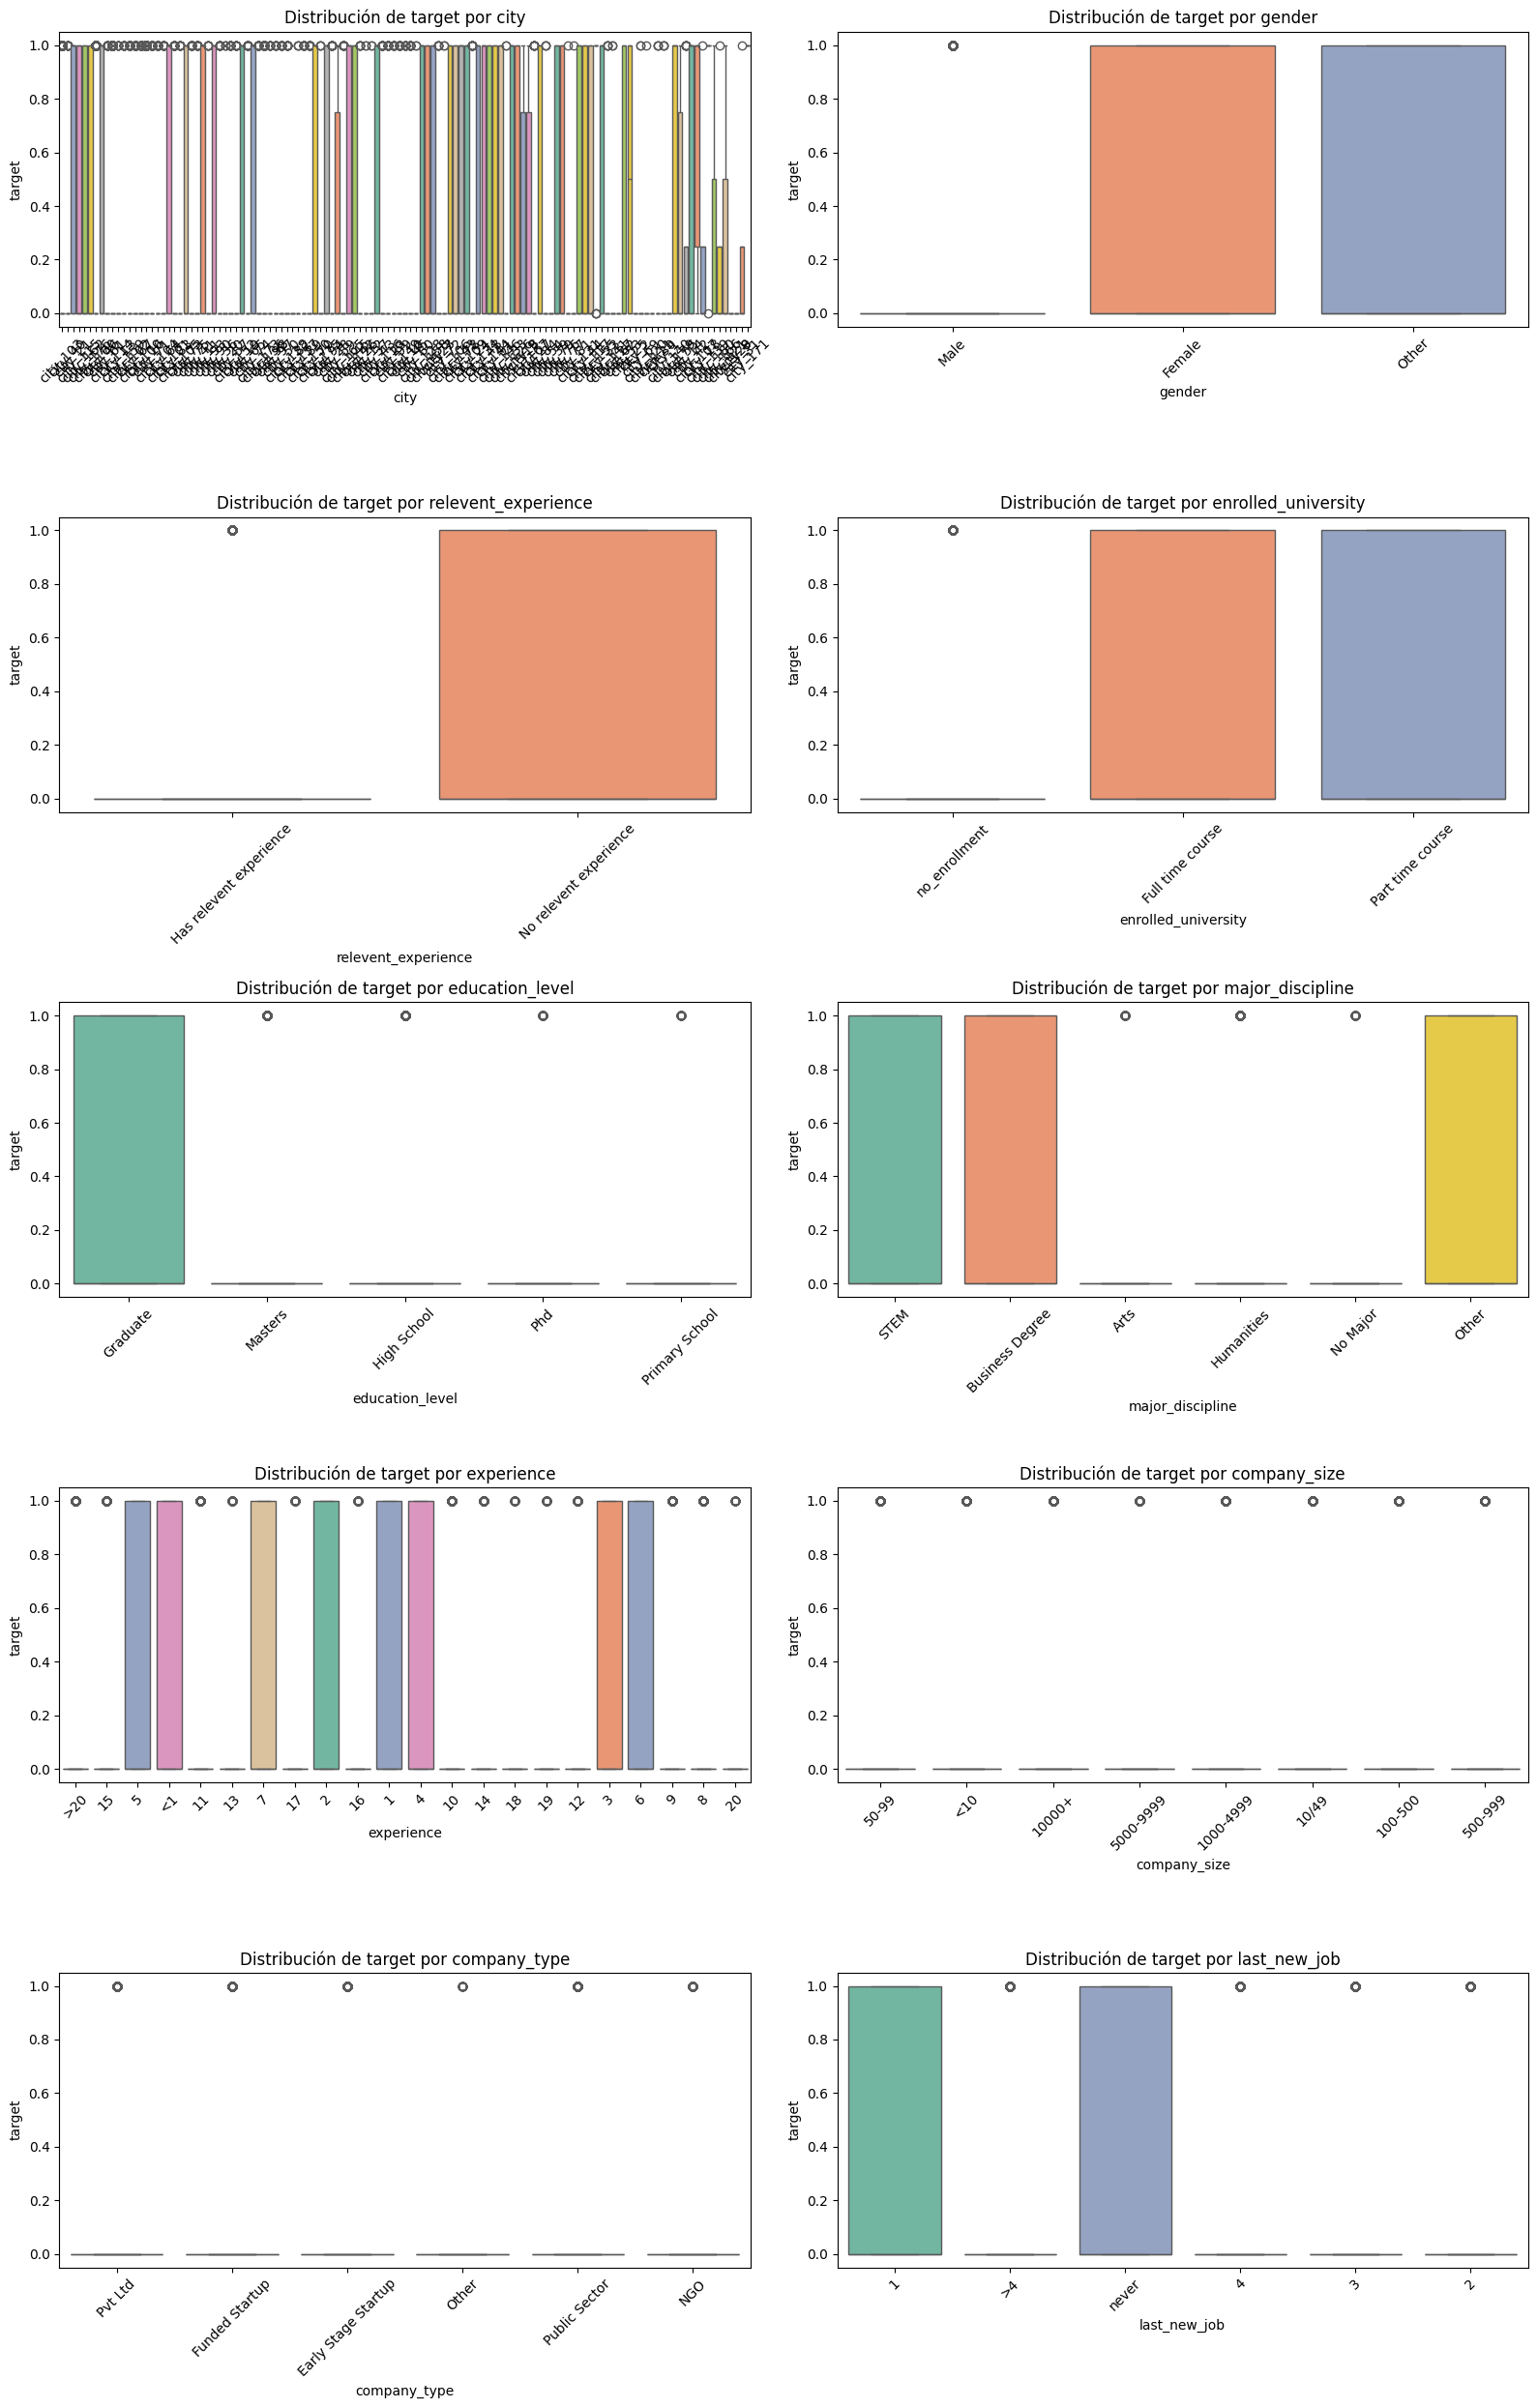

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar columnas categóricas
cat_cols = data.select_dtypes(include="object").columns

# Crear grid automático
n = len(cat_cols)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.boxplot(
        x=col,
        y="target",
        data=data,
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(f"Distribución de target por {col}")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel("target")

# Ocultar subplots vacíos
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

🧠 Conclusión general
Algunas variables categóricas (como relevent_experience, education_level, enrolled_university) sí muestran patrones claros.

Otras (como company_size, company_type) no aportan información útil para el target.

Los boxplots son útiles para detectar asimetrías y outliers, pero para un target binario, los barplots con medias son más interpretables.

In [27]:
col = "enrolled_university"
data.groupby(col)["target"].mean().sort_values(ascending=False)

enrolled_university
Full time course    0.380889
Part time course    0.252087
no_enrollment       0.211406
Name: target, dtype: float64

C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\1323204855.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="enrolled_university", y="target", data=data, estimator=np.mean, palette="Blues")


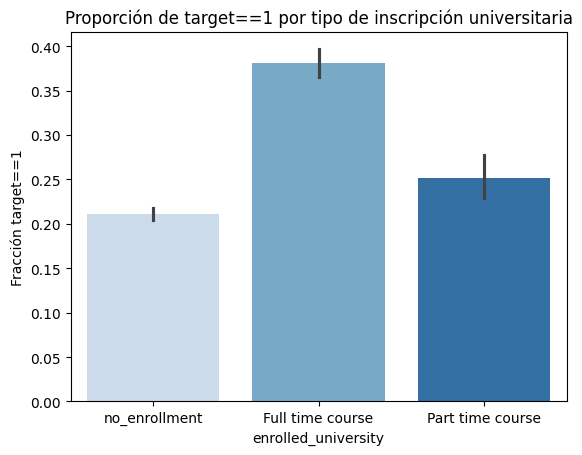

In [28]:
sns.barplot(x="enrolled_university", y="target", data=data, estimator=np.mean, palette="Blues")
plt.title("Proporción de target==1 por tipo de inscripción universitaria")
plt.ylabel("Fracción target==1")
plt.show()

🧠 Por qué el gráfico anterior se veía mal
El boxplot mostraba los valores individuales de target (0 o 1) por categoría, no la media.
Por eso todas las cajas parecían “planas” en 0 y 1, y no reflejaban la diferencia de proporciones.

Para visualizar correctamente esta diferencia, el mejor gráfico es el barplot con estimator=np.mean, que muestra la fracción promedio de target==1 por categoría.

In [33]:
from scipy.stats import chi2_contingency

tabla = pd.crosstab(data['enrolled_university'], data['target'])
chi2, p, dof, expected = chi2_contingency(tabla)

print("Chi2:", chi2)
print("p-value:", p)
print("Grados de libertad:", dof)
print("Esperados:\n", expected)

Chi2: 455.16676201857496
p-value: 1.451421175008096e-99
Grados de libertad: 2
Esperados:
 [[ 2825.55540166   931.44459834]
 [  900.98891967   297.01108033]
 [10391.45567867  3425.54432133]]


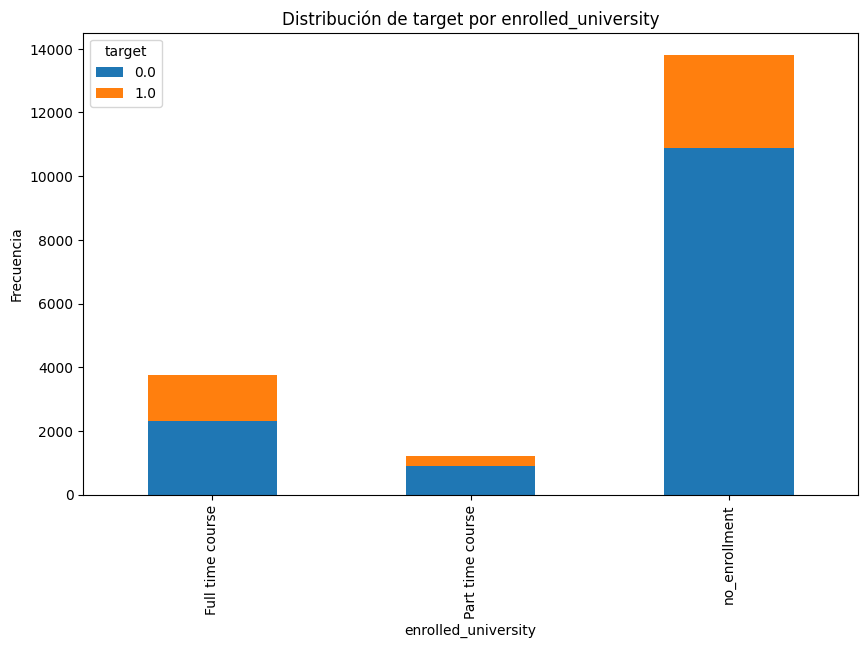

In [34]:
tabla.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Distribución de target por enrolled_university")
plt.xlabel("enrolled_university")
plt.ylabel("Frecuencia")
plt.show()

🔍 Interpretación estadística
No enrollment domina en frecuencia total, pero su proporción de target = 1 es la más baja (~21%).
👉 Esto sugiere que quienes no están inscritos en ninguna universidad tienen menor probabilidad de cumplir la condición del target.

Full time course tiene la mayor proporción de target = 1 (~38%).
👉 Indica que quienes estudian a tiempo completo son más propensos a estar en el grupo positivo del target.

Part time course queda en medio (~25%), mostrando una tendencia intermedia.

📊 Conclusión analítica
Hay una asociación clara entre el tipo de inscripción y el target:

A mayor compromiso académico (full‑time), mayor probabilidad de pertenecer al grupo objetivo.

Esto coincide con lo que el test Chi‑cuadrado confirmaría: una relación significativa entre ambas variables.

## 4. Análisis geoespacial

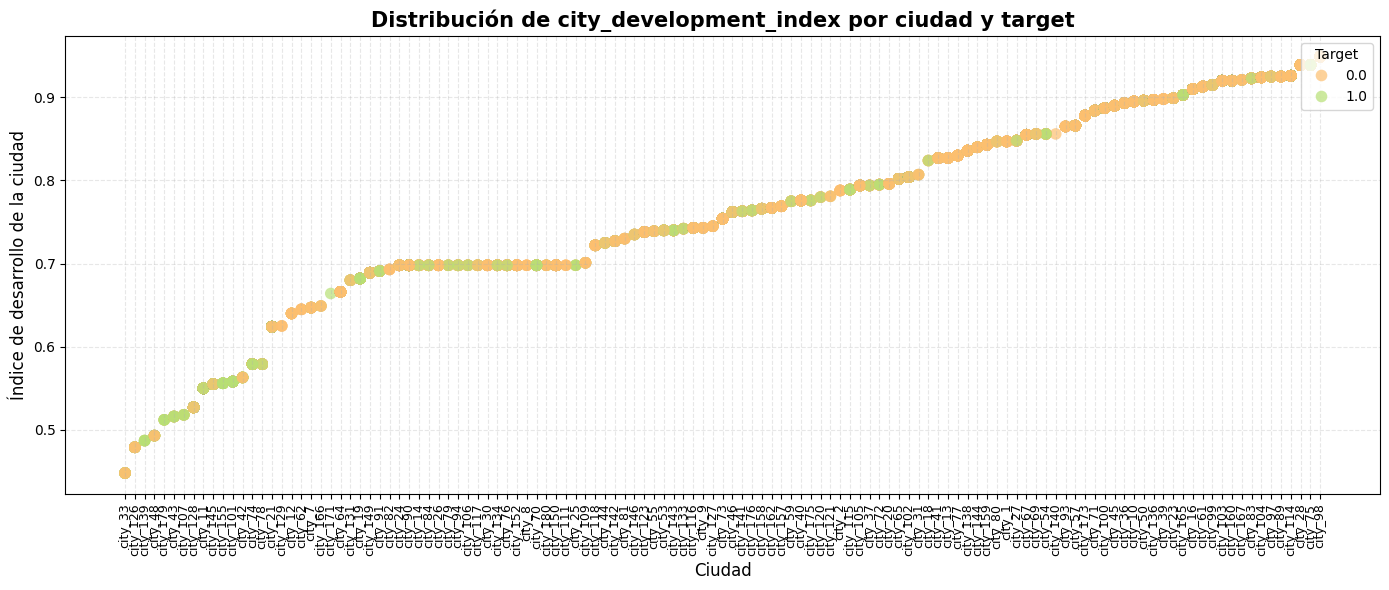


Conclusiones:
1️⃣ Las ciudades con mayor índice de desarrollo (≈0.85–0.95) concentran más puntos naranjas (target = 0),
    lo que sugiere menor proporción de individuos en el grupo objetivo.
2️⃣ Las ciudades con índices medios o bajos (≈0.5–0.7) muestran más puntos verdes (target = 1),
    indicando mayor probabilidad de pertenecer al grupo objetivo.
3️⃣ Existe una tendencia descendente: a menor desarrollo urbano, mayor probabilidad de target positivo.
4️⃣ Se recomienda complementar este análisis con boxplots o pruebas estadísticas (Chi-cuadrado o Kruskal)
    para confirmar la significancia de la relación observada.



In [40]:
# Ordenar las ciudades por índice de desarrollo para una lectura más clara
data_sorted = data.sort_values('city_development_index')

plt.figure(figsize=(14,6))
sns.scatterplot(
    x='city',
    y='city_development_index',
    hue='target',
    data=data_sorted,
    palette='RdYlGn',
    alpha=0.7,
    s=70,
    edgecolor='none'
)

# Personalización del gráfico
plt.title("Distribución de city_development_index por ciudad y target", fontsize=15, weight='bold')
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Índice de desarrollo de la ciudad", fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.legend(title="Target", loc='upper right')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 🧠 Conclusión analítica
print("""
Conclusiones:
1️⃣ Las ciudades con mayor índice de desarrollo (≈0.85–0.95) concentran más puntos naranjas (target = 0),
    lo que sugiere menor proporción de individuos en el grupo objetivo.
2️⃣ Las ciudades con índices medios o bajos (≈0.5–0.7) muestran más puntos verdes (target = 1),
    indicando mayor probabilidad de pertenecer al grupo objetivo.
3️⃣ Existe una tendencia descendente: a menor desarrollo urbano, mayor probabilidad de target positivo.
4️⃣ Se recomienda complementar este análisis con boxplots o pruebas estadísticas (Chi-cuadrado o Kruskal)
    para confirmar la significancia de la relación observada.
""")


---
## 5. Tratamiento de outliers

### ¿Qué hacemos aquí?
Identificamos y eliminamos valores extremos en las variables numéricas usando el método IQR (rango intercuartílico).

### El método IQR
Para cada variable:
- $Q1$ = percentil 25, $Q3$ = percentil 75, $IQR = Q3 - Q1$
- Límite inferior: $Q1 - k \times IQR$
- Límite superior: $Q3 + k \times IQR$
- Se eliminan las **filas** donde cualquier variable supera estos límites

**La elección del factor $k$ es una decisión importante:**
- $k = 1.5$: estándar de Tukey — elimina ~12% de los datos (muy agresivo si los outliers son reales)
- $k = 3$: conservador — elimina solo los extremos verdaderamente anómalos (~5%)

### ¿Por qué no usamos el target ni las coordenadas?
- No tratamos el target como outlier — los modelos tienen que aprender a predecir también esos casos.
- Usamos solo las variables numéricas.

In [46]:
df2 = data[['city_development_index', 'training_hours']].copy()
df2.head()

,city_development_index,training_hours
0,0.920,36
1,0.776,47
2,0.624,83
3,0.789,52
4,0.767,8


In [44]:
cols_para_outliers = cols_para_outliers = data[['city_development_index', 'training_hours']].columns.tolist()
def calcular_retencion(df, columns, k):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr =q3-q1
    lower =q1-k*iqr
    upper =q3+k*iqr
    mask = ~((df[columns]<lower)|(df[columns]>upper)).any(axis=1)
    return mask.sum(), mask.sum()/len(df) * 100

In [47]:
for k in [1.5,2,2.5,3,3.5]:
    n,pct=calcular_retencion(data, cols_para_outliers, k)
    print(f'{k:>10}|{n:>17}|{pct:>17}%')

       1.5|            18157|94.77502870863347%
         2|            18554|96.84727006994467%
       2.5|            18746|97.84946236559139%
         3|            18883|98.56456832654766%
       3.5|            19043|99.39972857291993%


In [51]:
# Escribe aquí tu código
def remove_outliers_iqr(df, columns, k=3):
    q1=df[columns].quantile(0.25)
    q3=df[columns].quantile(0.75)
    iqr =q3-q1
    lower =q1-k*iqr
    upper =q3+k*iqr
    mask = ~((df[columns]<lower)|(df[columns]>upper)).any(axis=1)
    return df[mask].copy()

data_clean = remove_outliers_iqr(data, cols_para_outliers, k=1.5)

In [52]:
data_clean

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19153,7386,city_173,0.878,Male,No relevent experience,no_enrollment,Graduate,Humanities,14,NaN,NaN,1,42,1.0
19154,31398,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,14,NaN,NaN,4,52,1.0
19155,24576,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,4,44,0.0
19156,5756,city_65,0.802,Male,Has relevent experience,no_enrollment,High School,NaN,<1,500-999,Pvt Ltd,2,97,0.0


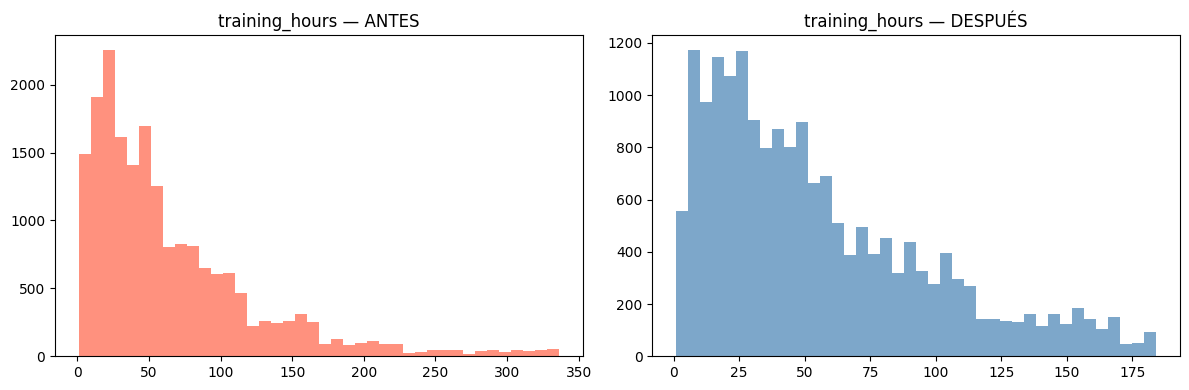

In [53]:
# Escribe aquí tu código
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(data['training_hours'], bins=40, color='tomato', alpha=0.7)
axes[0].set_title('training_hours — ANTES')
axes[1].hist(data_clean['training_hours'], bins=40, color='steelblue', alpha=0.7)
axes[1].set_title('training_hours — DESPUÉS')
plt.tight_layout()
plt.show()

## 6. Imputación de valores perdidos

In [54]:
data_clean['gender'] = data_clean['gender'].fillna('Unknown')

In [55]:
data_clean.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,Unknown,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


## 7. Feature Engineering


In [56]:
data_clean['last_new_job'].unique

array(['1', '>4', 'never', '4', '3', '2', nan], dtype=object)

In [59]:
# Mapeo ordinal basado en los valores reales de la columna
job_map = {
    'never': 0,
    '1': 1,
    '2': 2,
    '3': 3,
    '4': 4,
    '>4': 5
}

data_clean['last_new_job_num'] = data_clean['last_new_job'].map(job_map)


In [60]:
data_clean.head(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target,last_new_job_num
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0,5.0
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0,0.0
3,33241,city_115,0.789,Unknown,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0,0.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0,4.0


Variable	Transformación	Significado
training_effort_ratio	training_hours / city_development_index	Esfuerzo de formación relativo al nivel de desarrollo de la ciudad; mide cuánto “cuesta” formarse según el contexto urbano

In [61]:
data_clean['city_development_index_per_training_hours'] = data_clean['city_development_index'] / data_clean['training_hours']

C:\Users\alejo\AppData\Local\Temp\ipykernel_2160\1969171257.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


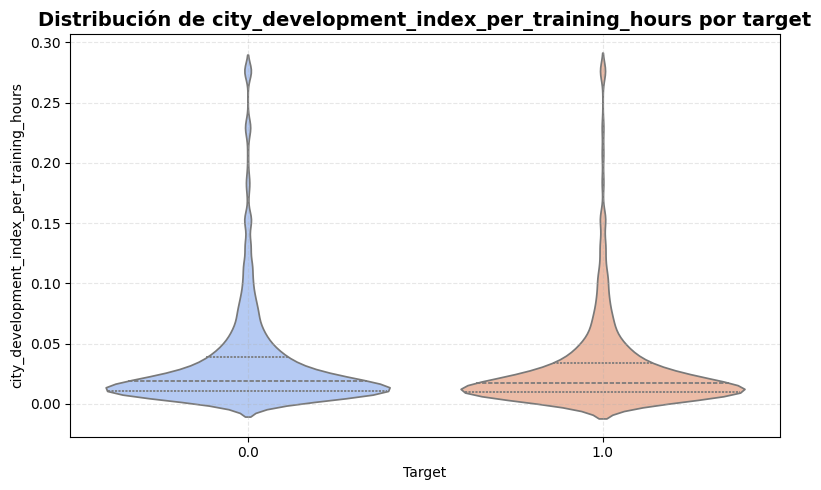

In [65]:
for col in vars_nuevas:
    p99 = data_clean[col].quantile(0.99)
    plt.figure(figsize=(8,5))
    sns.violinplot(
        data=data_clean,
        x='target',
        y=data_clean[col].clip(upper=p99),
        palette='coolwarm',
        inner='quartile'
    )
    plt.title(f"Distribución de {col} por target", fontsize=14, weight='bold')
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


<Axes: xlabel='education_level', ylabel='city_development_index_per_training_hours'>

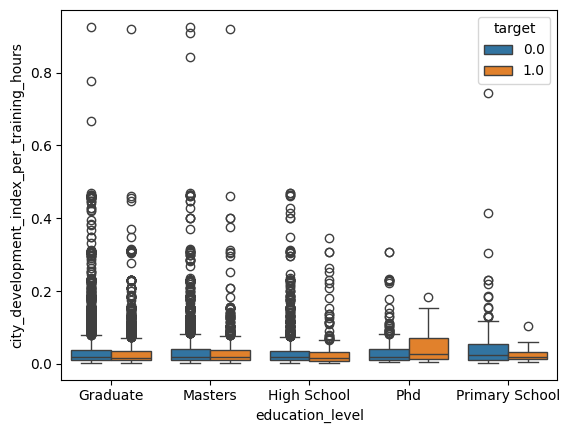

In [66]:
sns.boxplot(
    data=data_clean,
    x='education_level',
    y='city_development_index_per_training_hours',
    hue='target'
)

In [67]:
exp_map = {
    '<1': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8,
    '9': 9, '10': 10, '11': 11, '12': 12, '13': 13, '14': 14, '15': 15,
    '16': 16, '17': 17, '18': 18, '19': 19, '20': 20, '>20': 21
}

data_clean['experience_num'] = data_clean['experience'].map(exp_map)

In [68]:
# Evitar divisiones por cero o NaN
data_clean['training_hours_per_experience'] = (
    data_clean['training_hours'] /
    data_clean['experience_num'].replace(0, np.nan)
)

In [70]:
data_clean['training_hours_per_experience_log'] = np.log1p(data_clean['training_hours_per_experience'])

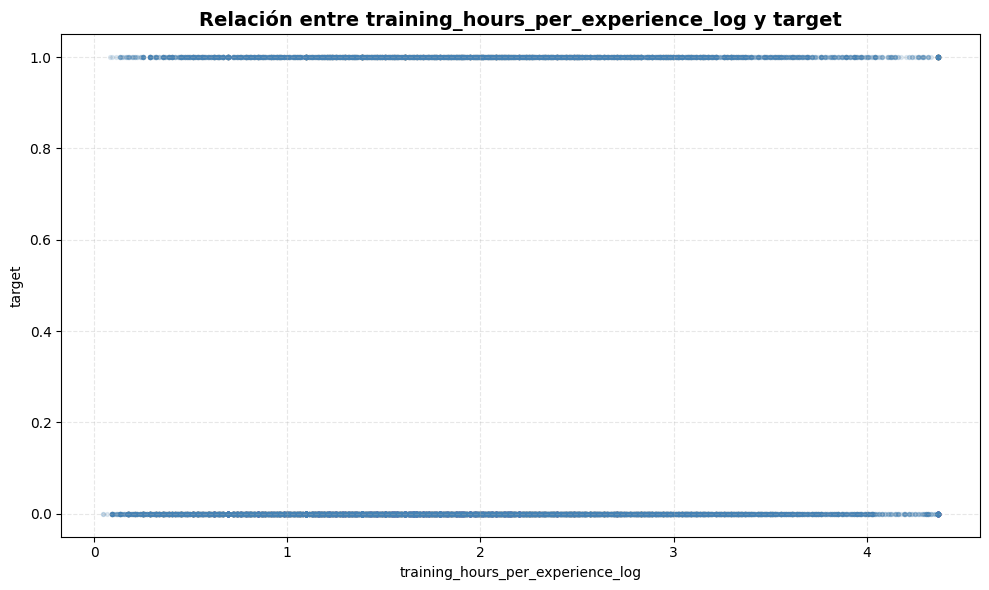

In [71]:
vars_nuevas = ['training_hours_per_experience_log']

for col in vars_nuevas:
    p99 = data_clean[col].quantile(0.99)

    plt.figure(figsize=(10,6))
    plt.scatter(
        data_clean[col].clip(upper=p99),
        data_clean['target'],
        alpha=0.15,
        s=8,
        color='steelblue'
    )

    plt.title(f"Relación entre {col} y target", fontsize=14, weight='bold')
    plt.xlabel(col)
    plt.ylabel('target')
    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()


<Axes: xlabel='relevent_experience', ylabel='training_hours_per_experience'>

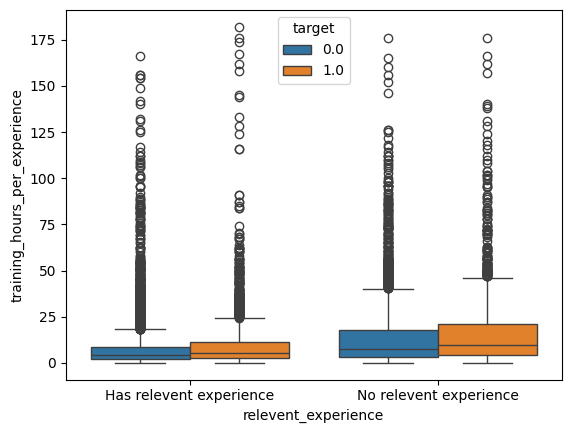

In [73]:
sns.boxplot(
    data=data_clean,
    x='relevent_experience',
    y='training_hours_per_experience',
    hue='target'
)

📊 Lectura del gráfico
Las personas sin experiencia relevante tienden a tener ratios más altos de training_hours_per_experience, especialmente en el grupo target = 1.
→ Esto sugiere que quienes no tienen experiencia previa y dedican más horas de formación podrían estar más interesados en cambiar de trabajo o mejorar su empleabilidad.

En cambio, quienes sí tienen experiencia relevante muestran ratios más bajos y más homogéneos, lo que indica menor necesidad de entrenamiento adicional.

---
## 8. Preparación final: OHE, Split y Escalado

### ¿Qué hacemos aquí?
Tres pasos finales antes de que los datos estén listos para cualquier modelo:
1. **One-Hot Encoding** — convertir la variable categórica a numéricas
2. **Split estratificado** en train / validación / test (70/15/15)
3. **Escalado** con StandardScaler — ajustado **solo** sobre el train

### Orden obligatorio: primero split, luego escalado

Este punto es crítico y se suele hacer mal. El escalado debe ajustarse **solo sobre el train** y aplicarse (transform) sobre val y test. Si ajustamos el scaler sobre todo el dataset antes del split, el modelo "ve" indirectamente información de val y test — esto se llama **data leakage** y produce métricas de validación optimistas que no se cumplen en producción.

In [ ]:
df = data_clean.copy()
df = pd.get_dummies(df, columns=['enrolled_university'])

In [ ]:
# safe check: original column may have been one-hot encoded already
if 'enrolled_university' in df.columns:
    print(df['enrolled_university'].value_counts())
else:
    # if one-hot encoded, aggregate the dummy columns
    dummy_cols = [c for c in df.columns if c.startswith('enrolled_university_')]
    if dummy_cols:
        counts = {c.replace('enrolled_university_', ''): int(df[c].sum()) for c in dummy_cols}
        print(pd.Series(counts))
    else:
        # fallback to original cleaned dataframe
        print(data_clean['enrolled_university'].value_counts())

In [ ]:
df.head()

In [ ]:
df.columns

repasar entrenamiento